# Prediksi Jangka Panjang Harga Emas Menggunakan Algoritma ARIMA

---

| Keterangan | Detail |
|---|---|
| **Mata Kuliah** | AI in Business |
| **Topik** | Time Series Forecasting |
| **Algoritma** | ARIMA (AutoRegressive Integrated Moving Average) |
| **Dataset** | Gold Futures (GC=F) dari Yahoo Finance |

---

## 1. Pendahuluan Proyek

### Apa itu Forecasting (Peramalan)?
Forecasting atau peramalan adalah proses membuat prediksi tentang nilai-nilai di masa depan berdasarkan data masa lalu dan saat ini. Peramalan digunakan secara luas di berbagai bidang seperti ekonomi, keuangan, prediksi cuaca, dan manajemen rantai pasokan. Tujuan utamanya adalah memanfaatkan pola historis untuk memperkirakan apa yang akan terjadi selanjutnya.

### Apa itu Time Series Forecasting?
Time series forecasting adalah jenis peramalan khusus di mana titik-titik data dikumpulkan atau dicatat pada interval waktu yang teratur. Tidak seperti masalah regresi standar, data time series memiliki urutan temporal, artinya urutan observasi sangat penting. Contohnya meliputi harga saham harian, penjualan bulanan, dan pembacaan suhu per jam.

### Apa itu ARIMA?
**ARIMA** merupakan singkatan dari **AutoRegressive Integrated Moving Average**. Model ini adalah salah satu model statistik yang paling banyak digunakan untuk peramalan time series. ARIMA menggabungkan tiga komponen utama:

- **AR (AutoRegressive)** — menggunakan hubungan antara observasi saat ini dengan sejumlah observasi sebelumnya (parameter **p**).
- **I (Integrated)** — melibatkan differencing data untuk membuatnya stasioner (parameter **d**).
- **MA (Moving Average)** — menggunakan ketergantungan antara observasi dan kesalahan residual dari moving average pada observasi sebelumnya (parameter **q**).

Model ditulis sebagai **ARIMA(p, d, q)**.

### Mengapa Harga Emas?
Emas telah menjadi penyimpan nilai yang andal selama berabad-abad. Harganya dipengaruhi oleh banyak faktor global termasuk inflasi, ketegangan geopolitik, fluktuasi mata uang, dan sentimen investor. Meramalkan harga emas sangat berharga bagi investor, analis keuangan, dan pembuat kebijakan.

### Pentingnya Forecasting dalam Keuangan
Peramalan keuangan yang akurat membantu:
- **Investor** membuat keputusan beli/jual yang lebih tepat.
- **Manajer risiko** melakukan lindung nilai terhadap volatilitas harga.
- **Lembaga keuangan** merencanakan alokasi modal.
- **Pemerintah** merancang kebijakan moneter yang lebih baik.

Dalam proyek ini, kita akan membangun model ARIMA dari awal hingga akhir untuk meramalkan harga emas **30 hari ke depan** menggunakan data historis dari Yahoo Finance.

---
## 2. Instalasi Library yang Diperlukan

Sebelum memulai analisis, kita perlu memastikan semua library Python yang dibutuhkan sudah terinstal di lingkungan kita. Jalankan sel di bawah ini terlebih dahulu untuk menginstal semua dependensi secara otomatis.

Library yang akan diinstal:
- `yfinance` — untuk mengunduh data keuangan dari Yahoo Finance
- `statsmodels` — untuk model statistik termasuk ARIMA
- `scikit-learn` — untuk metrik evaluasi model
- `seaborn` — untuk visualisasi data yang lebih estetis
- `pandas`, `numpy`, `matplotlib` — library dasar untuk analisis dan visualisasi data

In [1]:
# Instalasi otomatis semua library yang diperlukan
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

required_packages = ['yfinance', 'statsmodels', 'scikit-learn', 'seaborn', 'pandas', 'numpy', 'matplotlib']

for package in required_packages:
    install(package)
    print(f'Berhasil diinstal: {package}')

print('\nSemua library siap digunakan!')

Berhasil diinstal: yfinance
Berhasil diinstal: statsmodels
Berhasil diinstal: scikit-learn
Berhasil diinstal: seaborn
Berhasil diinstal: pandas
Berhasil diinstal: numpy
Berhasil diinstal: matplotlib

Semua library siap digunakan!


> Proses instalasi di atas hanya perlu dijalankan sekali. Jika library sudah terinstal sebelumnya, perintah di atas akan memverifikasi keberadaannya tanpa menginstal ulang.

---
## 3. Import Library

Setelah semua library terinstal, kita mengimport semua modul yang diperlukan ke dalam notebook. Setiap library memiliki peran spesifik dalam alur kerja proyek ini:

| Library | Fungsi |
|---|---|
| `pandas` | Manipulasi dan analisis data tabular |
| `numpy` | Operasi numerik dan array |
| `yfinance` | Mengunduh data harga saham/komoditas dari Yahoo Finance |
| `statsmodels` | Model ARIMA, ADF test, ACF/PACF |
| `sklearn.metrics` | Menghitung MSE dan MAE |
| `matplotlib` | Visualisasi grafik dasar |
| `seaborn` | Visualisasi statistik yang lebih canggih |

In [2]:
# Library utama untuk manipulasi data
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path

# Library untuk mengunduh data dari Yahoo Finance
import yfinance as yf

# Library untuk analisis time series dan model ARIMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Library untuk metrik evaluasi model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Library untuk visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Menonaktifkan peringatan untuk output yang lebih bersih
import warnings
warnings.filterwarnings('ignore')

# Mengatur gaya plot secara global
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Menyiapkan folder output
OUTPUT_DIR = Path('reports/hasil')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Semua library berhasil diimport!')
print(f'Output folder: {OUTPUT_DIR.resolve()}')
print(f'Pandas  : v{pd.__version__}')
print(f'NumPy   : v{np.__version__}')
print(f'yfinance: v{yf.__version__}')

Semua library berhasil diimport!
Output folder: D:\Bahan Kuliah UGM\Tugas AI in Business\Prediksi Harga\reports\hasil
Pandas  : v3.0.3
NumPy   : v2.4.6
yfinance: v1.3.0


> **Catatan:** Pesan konfirmasi di atas menunjukkan bahwa semua library telah berhasil diimport. Versi library ditampilkan untuk keperluan reproduksi hasil analisis di kemudian hari.

---
## 4. Pengunduhan Dataset

Kita mengunduh data harga emas langsung dari Yahoo Finance menggunakan library `yfinance`. Data yang diunduh adalah harga penutupan (Close price) harian Gold Futures dengan kode ticker **GC=F**.

**Spesifikasi data:**
- **Ticker:** `GC=F` (Gold Futures — kontrak berjangka emas di COMEX)
- **Tanggal mulai:** 1 Januari 2020 (minimal 5 tahun data historis)
- **Tanggal akhir:** Hari ini (diambil secara otomatis)
- **Interval:** Harian (daily)

Gold Futures dipilih karena merepresentasikan harga emas standar internasional yang diperdagangkan di bursa berjangka Chicago Mercantile Exchange (CME).

In [3]:
# Parameter pengunduhan data
TICKER     = 'GC=F'          # Kode ticker Gold Futures di Yahoo Finance
START_DATE = '2020-01-01'    # Tanggal mulai — minimal 5 tahun data
END_DATE   = datetime.today().strftime('%Y-%m-%d')  # Tanggal hari ini (otomatis)

print('Mengunduh data Gold Futures dari Yahoo Finance...')
print(f'Ticker     : {TICKER}')
print(f'Tanggal Mulai : {START_DATE}')
print(f'Tanggal Akhir : {END_DATE}')
print()

# Mengunduh data menggunakan yfinance
gold_data = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=True)

# Meratakan MultiIndex kolom jika ada (yfinance terkadang mengembalikan MultiIndex)
if isinstance(gold_data.columns, pd.MultiIndex):
    gold_data.columns = gold_data.columns.get_level_values(0)

print(f'\nData berhasil diunduh!')
print(f'Total baris data: {len(gold_data)}')
print(f'Periode data    : {gold_data.index[0].date()} sampai {gold_data.index[-1].date()}')

Mengunduh data Gold Futures dari Yahoo Finance...
Ticker     : GC=F
Tanggal Mulai : 2020-01-01
Tanggal Akhir : 2026-05-21



[*********************100%***********************]  1 of 1 completed


Data berhasil diunduh!
Total baris data: 1606
Periode data    : 2020-01-02 sampai 2026-05-20


> **Hasil:** Data berhasil diunduh dari Yahoo Finance sebanyak **1606 baris** hari perdagangan.
> Periode data: **2020-01-02** s.d. **2026-05-20** (hingga data terakhir yang tersedia).

---
## 5. Tinjauan Dataset (Dataset Overview)

Sebelum melakukan analisis, kita perlu memahami struktur dan karakteristik dataset yang telah diunduh. Tahap ini disebut **data understanding** — bagian penting dari metodologi analisis data.

### Penjelasan Kolom Dataset

| Kolom | Deskripsi |
|---|---|
| **Date** | Tanggal perdagangan (digunakan sebagai indeks) |
| **Open** | Harga emas saat pasar dibuka |
| **High** | Harga tertinggi emas sepanjang hari perdagangan |
| **Low** | Harga terendah emas sepanjang hari perdagangan |
| **Close** | Harga emas saat pasar ditutup (**variabel target prediksi**) |
| **Volume** | Jumlah kontrak yang diperdagangkan pada hari tersebut |

Kolom **Close** dipilih sebagai variabel target karena merepresentasikan konsensus akhir pasar setiap harinya dan paling sering digunakan dalam analisis harga aset keuangan.

In [4]:
# Menampilkan 5 baris pertama dataset
print('=== 5 Baris Pertama Dataset ===')
display(gold_data.head())

=== 5 Baris Pertama Dataset ===


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214
2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107
2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416
2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47
2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236


> Lima baris pertama di atas menunjukkan data awal dari Januari 2020. Terlihat bahwa harga emas pada awal 2020 berada di kisaran USD 1.500-1.600 per troy ounce.

In [5]:
# Menampilkan 5 baris terakhir dataset
print('=== 5 Baris Terakhir Dataset ===')
display(gold_data.tail())

=== 5 Baris Terakhir Dataset ===


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-05-14,4678.100098,4678.100098,4650.299805,4678.100098,5
2026-05-15,4555.799805,4615.200195,4524.299805,4615.200195,607
2026-05-18,4552.500000,4570.299805,4538.700195,4563.000000,38
2026-05-19,4506.299805,4552.600098,4506.200195,4551.700195,875
2026-05-20,4531.299805,4531.299805,4465.100098,4502.600098,875


> Lima baris terakhir menunjukkan data terbaru yang diunduh. Bandingkan dengan baris pertama untuk melihat perubahan harga emas selama periode pengamatan.

In [6]:
# Ukuran dan tipe data dataset
print('=== Ukuran Dataset ===')
print(f'Jumlah Baris  : {gold_data.shape[0]}')
print(f'Jumlah Kolom  : {gold_data.shape[1]}')
print()
print('=== Tipe Data Setiap Kolom ===')
print(gold_data.dtypes)

=== Ukuran Dataset ===
Jumlah Baris  : 1606
Jumlah Kolom  : 5

=== Tipe Data Setiap Kolom ===
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


> Semua kolom harga (Open, High, Low, Close) bertipe `float64`, sedangkan Volume bertipe `int64`.
> Ini memastikan data numerik siap untuk analisis statistik dan pemodelan.

In [7]:
# Memeriksa nilai yang hilang (missing values)
print('=== Pemeriksaan Nilai yang Hilang ===')
missing = gold_data.isnull().sum()
print(missing)
print(f'\nTotal nilai yang hilang: {missing.sum()}')

=== Pemeriksaan Nilai yang Hilang ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Total nilai yang hilang: 0


> Tidak ditemukan nilai yang hilang pada data yang diunduh (total missing = 0).
> Artinya data historis sudah lengkap dan bisa langsung diproses.

In [8]:
# Ringkasan statistik deskriptif
print('=== Ringkasan Statistik Deskriptif ===')
display(gold_data.describe().round(2))

=== Ringkasan Statistik Deskriptif ===


Price,Close,High,Low,Open,Volume
count,1606.00,1606.00,1606.00,1606.00,1606.00
mean,2347.88,2361.70,2333.49,2347.62,4276.84
std,879.97,889.85,870.25,881.12,22433.48
min,1477.30,1484.00,1452.10,1469.30,0.00
25%,1799.77,1807.43,1791.70,1799.58,95.00
50%,1932.80,1942.75,1922.50,1932.45,306.00
75%,2625.03,2631.00,2615.10,2624.68,822.00
max,5318.40,5586.20,5301.60,5415.70,251274.00


> **Interpretasi statistik deskriptif (kolom Close):**
> - **mean** sekitar **2361.70 USD** menunjukkan rata-rata harga emas selama 2020-sekarang
> - **min** **1484.00 USD** dan **max** **5586.20 USD** menunjukkan rentang harga yang lebar
> - **std** yang besar mencerminkan volatilitas yang meningkat pada periode tertentu

---
## 6. Eksplorasi Data (Exploratory Data Analysis / EDA)

EDA adalah proses memvisualisasikan dan mengeksplorasi data untuk menemukan pola, anomali, dan wawasan penting sebelum membangun model. Dalam proyek ini, kita akan membuat 6 visualisasi utama:

1. Grafik harga historis emas
2. Moving average 7 hari
3. Moving average 30 hari
4. Visualisasi return harian
5. Distribusi harga Close
6. Grafik volume perdagangan

### Visualisasi 1 & 2 & 3: Harga Historis dan Moving Average

Moving average (rata-rata bergerak) adalah teknik umum dalam analisis keuangan untuk menghaluskan fluktuasi jangka pendek dan mengidentifikasi tren yang mendasarinya.
- **MA 7 hari** → menangkap tren jangka pendek (mingguan)
- **MA 30 hari** → menangkap tren jangka menengah (bulanan)

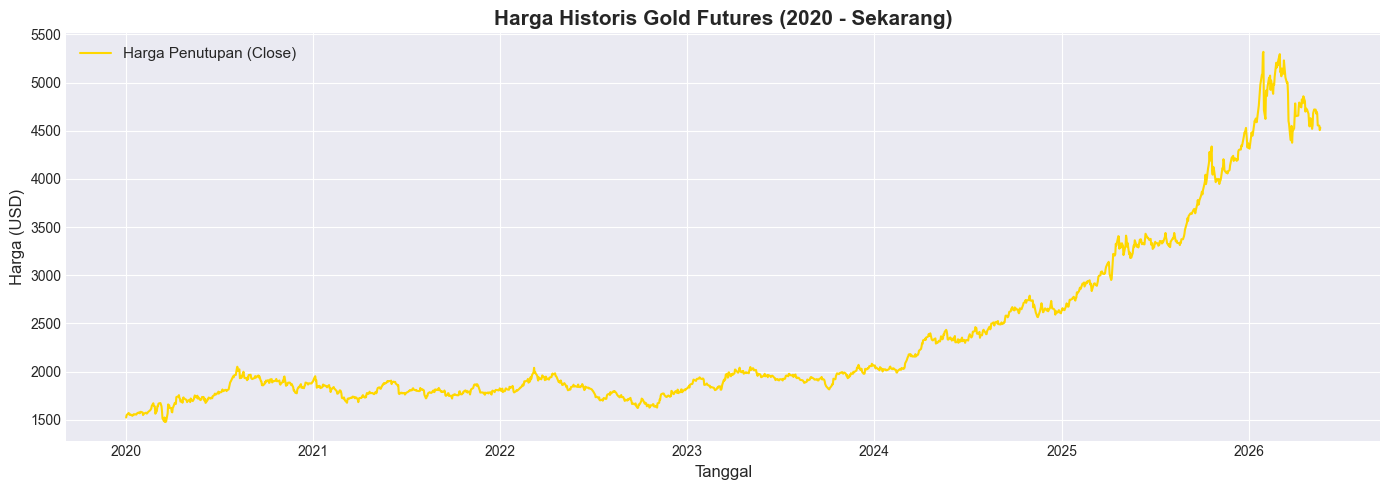

In [9]:
# Menghitung moving average 7 hari dan 30 hari
gold_data['MA7']  = gold_data['Close'].rolling(window=7).mean()
gold_data['MA30'] = gold_data['Close'].rolling(window=30).mean()

# Visualisasi 1: Harga Close historis
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gold_data.index, gold_data['Close'], color='gold', linewidth=1.5, label='Harga Penutupan (Close)')
ax.set_title('Harga Historis Gold Futures (2020 - Sekarang)', fontsize=15, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('Harga (USD)', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

> **Insight Grafik 1:** Harga emas menunjukkan tren naik yang kuat sejak 2020, dengan akselerasi kenaikan pada 2024-2026.
> Terlihat koreksi tajam menjelang Mei 2026 yang kemudian diikuti fase konsolidasi.

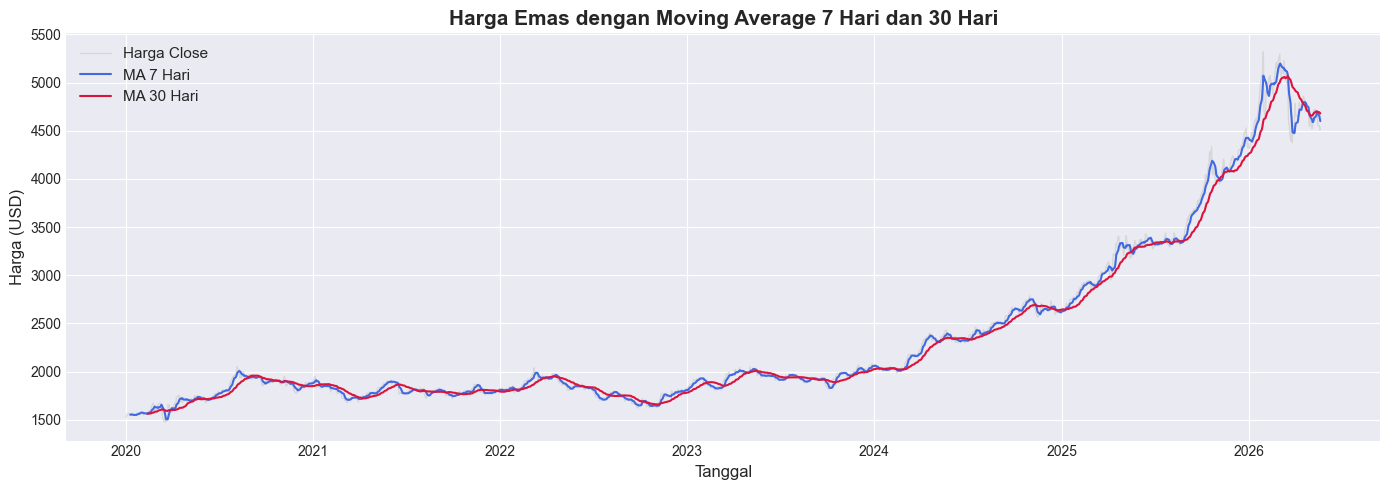

In [10]:
# Visualisasi 2 & 3: Moving Average 7 hari dan 30 hari
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gold_data.index, gold_data['Close'], color='lightgray',  linewidth=1,   label='Harga Close', alpha=0.8)
ax.plot(gold_data.index, gold_data['MA7'],   color='royalblue',  linewidth=1.5, label='MA 7 Hari')
ax.plot(gold_data.index, gold_data['MA30'],  color='crimson',    linewidth=1.5, label='MA 30 Hari')
ax.set_title('Harga Emas dengan Moving Average 7 Hari dan 30 Hari', fontsize=15, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('Harga (USD)', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

> **Insight Grafik 2 & 3:** Ketika MA 7 hari memotong MA 30 hari dari bawah ke atas (golden cross), ini sering menjadi sinyal beli dalam analisis teknikal. Sebaliknya, ketika MA 7 memotong MA 30 dari atas ke bawah (death cross), ini menjadi sinyal jual. Terlihat pola tren yang jelas dari persilangan kedua moving average.

### Visualisasi 4: Return Harian

Return harian menunjukkan persentase perubahan harga dari satu hari ke hari berikutnya. Ini adalah cara standar untuk mengukur volatilitas aset keuangan dan memahami seberapa besar harga berfluktuasi setiap harinya.

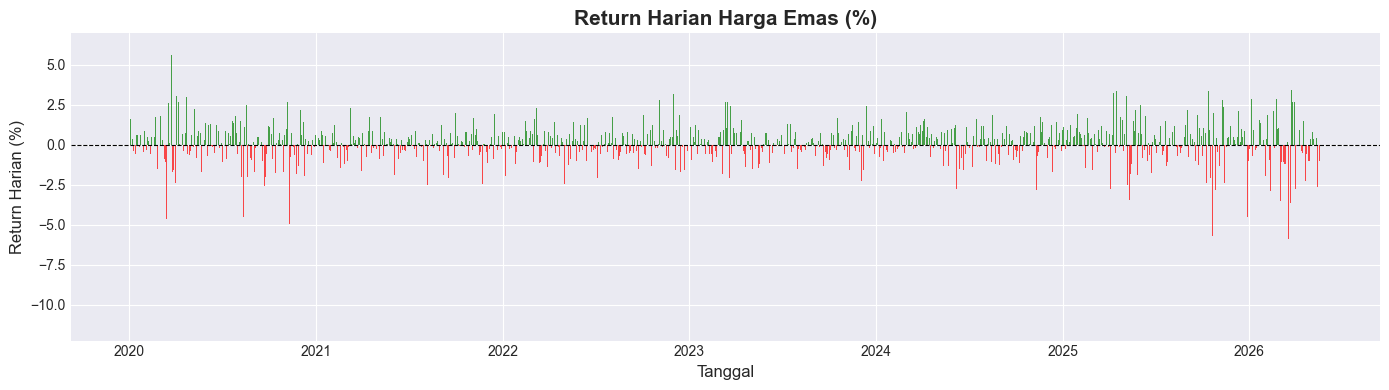

Rata-rata Return Harian : 0.0748%
Std Dev Return Harian   : 1.1753%
Return Harian Maksimum  : 6.0833%
Return Harian Minimum   : -11.3662%


In [11]:
# Menghitung return harian dalam persen
gold_data['Return_Harian'] = gold_data['Close'].pct_change() * 100

# Visualisasi 4: Return harian
fig, ax = plt.subplots(figsize=(14, 4))
colors = gold_data['Return_Harian'].apply(lambda x: 'green' if x >= 0 else 'red')
ax.bar(gold_data.index, gold_data['Return_Harian'], color=colors, alpha=0.7, width=1)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Return Harian Harga Emas (%)', fontsize=15, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('Return Harian (%)', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f'Rata-rata Return Harian : {gold_data["Return_Harian"].mean():.4f}%')
print(f'Std Dev Return Harian   : {gold_data["Return_Harian"].std():.4f}%')
print(f'Return Harian Maksimum  : {gold_data["Return_Harian"].max():.4f}%')
print(f'Return Harian Minimum   : {gold_data["Return_Harian"].min():.4f}%')

> **Insight Grafik 4:** Return harian rata-rata sebesar **0.0748%** dengan deviasi standar **1.1753%**, menunjukkan volatilitas moderat.
> Return maksimum **6.0833%** dan minimum **-11.3662%** menandakan adanya hari-hari ekstrem (shock) di periode tertentu.

### Visualisasi 5: Distribusi Harga Close

Memahami distribusi harga membantu kita mengetahui apakah harga emas terdistribusi normal atau memiliki kemiringan (skewness). Informasi ini penting untuk memilih metode statistik yang tepat.

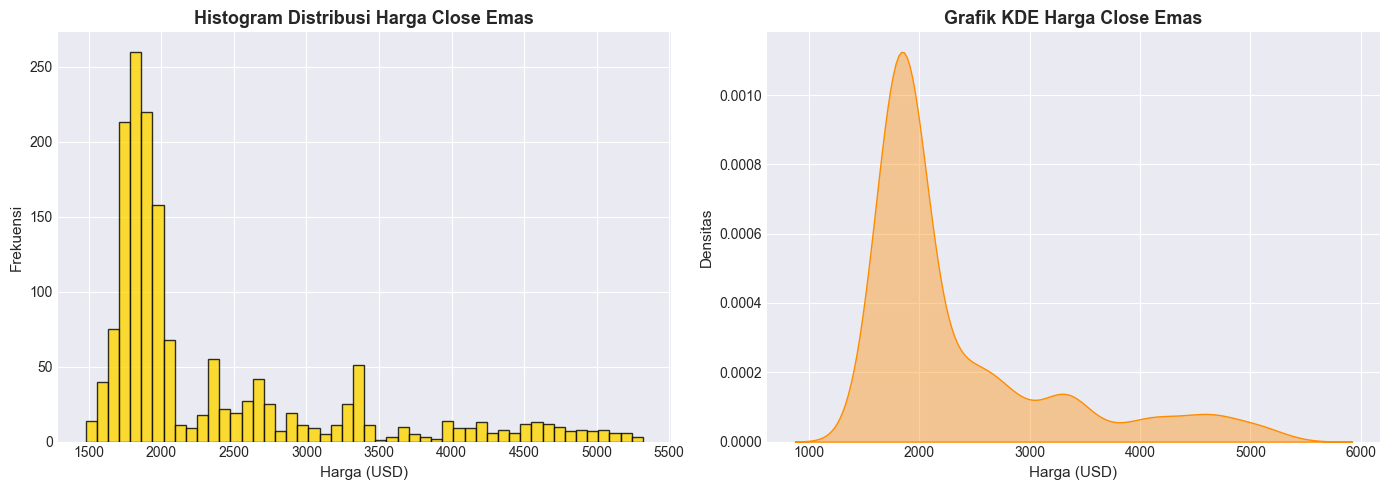

Skewness (Kemiringan) : 1.6780
Kurtosis              : 1.8371


In [12]:
# Visualisasi 5: Distribusi harga Close
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(gold_data['Close'].dropna(), bins=50, color='gold', edgecolor='black', alpha=0.8)
axes[0].set_title('Histogram Distribusi Harga Close Emas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga (USD)', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)

# KDE Plot (Kernel Density Estimation)
sns.kdeplot(gold_data['Close'].dropna(), ax=axes[1], color='darkorange', fill=True, alpha=0.4)
axes[1].set_title('Grafik KDE Harga Close Emas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Harga (USD)', fontsize=11)
axes[1].set_ylabel('Densitas', fontsize=11)

plt.tight_layout()
plt.show()

skewness = gold_data['Close'].skew()
kurtosis = gold_data['Close'].kurtosis()
print(f'Skewness (Kemiringan) : {skewness:.4f}')
print(f'Kurtosis              : {kurtosis:.4f}')

> **Insight Grafik 5:** Distribusi harga emas condong ke kanan (right-skewed) dengan **skewness = 1.678**.
> Nilai **kurtosis = 1.837** menunjukkan ekor distribusi yang relatif tebal (lebih banyak outlier dibanding normal).

### Visualisasi 6: Volume Perdagangan

Volume perdagangan menunjukkan jumlah kontrak emas yang diperdagangkan setiap harinya. Volume yang tinggi sering mengindikasikan tingginya minat pasar dan dapat menjadi konfirmasi pergerakan harga.

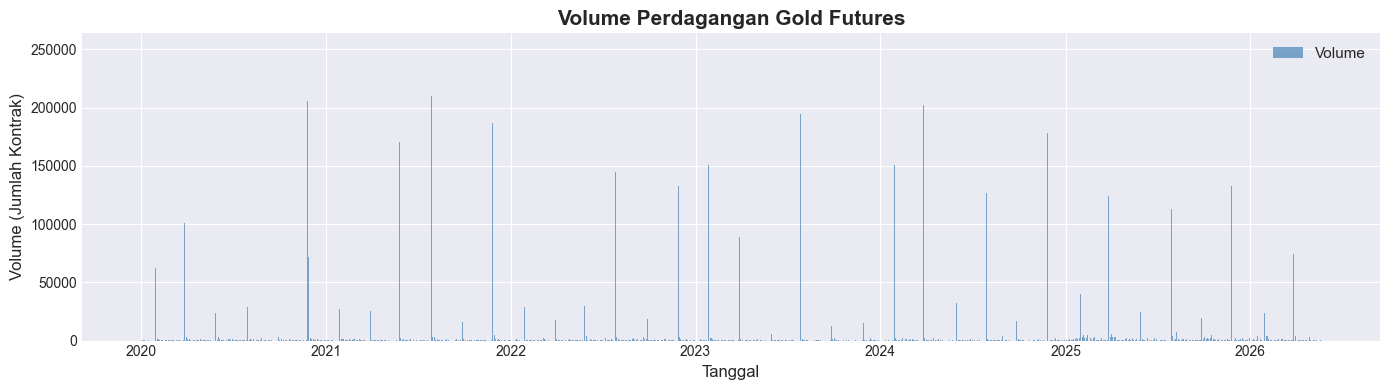

Rata-rata Volume Harian : 4,277 kontrak
Volume Maksimum         : 251,274 kontrak


In [13]:
# Visualisasi 6: Volume perdagangan
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(gold_data.index, gold_data['Volume'], color='steelblue', alpha=0.7, width=1, label='Volume')
ax.set_title('Volume Perdagangan Gold Futures', fontsize=15, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=12)
ax.set_ylabel('Volume (Jumlah Kontrak)', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print(f'Rata-rata Volume Harian : {gold_data["Volume"].mean():,.0f} kontrak')
print(f'Volume Maksimum         : {gold_data["Volume"].max():,.0f} kontrak')

> **Insight Grafik 6:** Rata-rata volume harian sekitar **4,277 kontrak**, dengan puncak volume **251,274 kontrak**.
> Lonjakan volume biasanya bertepatan dengan peristiwa ekonomi besar dan sering memperkuat sinyal tren harga.

---
## 7. Pra-pemrosesan Data (Data Preprocessing)

Pra-pemrosesan data adalah langkah krusial untuk memastikan kualitas data sebelum dimasukkan ke dalam model. Untuk time series forecasting dengan ARIMA, kita perlu:

1. **Konversi format tanggal** — memastikan indeks bertipe datetime
2. **Pengurutan data** — data harus berurutan kronologis
3. **Penanganan nilai hilang** — menggunakan metode forward-fill yang tepat untuk data time series
4. **Seleksi variabel target** — mengambil hanya kolom Close untuk pemodelan

Setiap langkah akan dijelaskan dan diverifikasi hasilnya.

In [14]:
# Langkah 1: Memastikan indeks dalam format datetime
gold_data.index = pd.to_datetime(gold_data.index)
print('Langkah 1 SELESAI: Indeks tanggal dikonversi ke format datetime')
print(f'Tipe indeks sekarang: {type(gold_data.index)}')
print()

# Langkah 2: Mengurutkan data berdasarkan tanggal (ascending)
gold_data = gold_data.sort_index()
print('Langkah 2 SELESAI: Data diurutkan berdasarkan tanggal (dari yang terlama)')
print()

# Langkah 3: Menangani nilai yang hilang menggunakan forward-fill
# Forward-fill: nilai yang hilang diisi dengan nilai terakhir yang valid
# Metode ini lebih tepat untuk time series daripada interpolasi atau menghapus baris
gold_data = gold_data.ffill()
sisa_missing = gold_data.isnull().sum().sum()
print('Langkah 3 SELESAI: Nilai yang hilang ditangani dengan metode forward-fill')
print(f'Sisa nilai yang hilang: {sisa_missing}')
print()

# Langkah 4: Mengekstrak kolom Close sebagai variabel target
# Kita fokus pada harga penutupan karena merepresentasikan nilai akhir setiap hari perdagangan
close_series = gold_data['Close'].copy()
close_series.name = 'Harga Penutupan Emas (USD)'
print('Langkah 4 SELESAI: Deret harga Close berhasil diekstrak sebagai variabel target')
print(f'Jumlah data: {len(close_series)} hari perdagangan')
print()

# Langkah 5: Menyimpan data yang sudah diproses ke CSV
gold_data.to_csv(OUTPUT_DIR / 'gold_data.csv')
print(f'Langkah 5 SELESAI: Data disimpan ke file {OUTPUT_DIR / "gold_data.csv"}')
print()
print('Pra-pemrosesan data selesai!')
print()
display(close_series.tail())

Langkah 1 SELESAI: Indeks tanggal dikonversi ke format datetime
Tipe indeks sekarang: <class 'pandas.DatetimeIndex'>

Langkah 2 SELESAI: Data diurutkan berdasarkan tanggal (dari yang terlama)

Langkah 3 SELESAI: Nilai yang hilang ditangani dengan metode forward-fill
Sisa nilai yang hilang: 36

Langkah 4 SELESAI: Deret harga Close berhasil diekstrak sebagai variabel target
Jumlah data: 1606 hari perdagangan

Langkah 5 SELESAI: Data disimpan ke file reports\hasil\gold_data.csv

Pra-pemrosesan data selesai!



Date
2026-05-14    4678.100098
2026-05-15    4555.799805
2026-05-18    4552.500000
2026-05-19    4506.299805
2026-05-20    4531.299805
Name: Harga Penutupan Emas (USD), dtype: float64

> **Hasil Preprocessing:** Semua langkah berhasil dieksekusi. Data sekarang siap untuk analisis lebih lanjut:
> - Indeks sudah dalam format datetime yang konsisten
> - Data terurut kronologis dari yang terlama hingga terbaru
> - Tidak ada nilai yang hilang tersisa
> - Variabel target (Close price) telah diisolasi sebagai deret waktu (time series)

---
## 8. Visualisasi Time Series

Setelah preprocessing, kita memvisualisasikan **rolling statistics** (statistik bergerak) untuk mendapatkan gambaran awal tentang sifat stasioneritas data.

### Konsep Stasioneritas

Sebuah time series dikatakan **stasioner** jika memiliki sifat-sifat statistik yang **konstan sepanjang waktu**:
- **Rata-rata (mean)** tidak berubah seiring waktu
- **Varians** tidak berubah seiring waktu
- **Autokorelasi** tidak bergantung pada waktu

### Mengapa Stasioneritas Penting untuk ARIMA?
Model ARIMA mengasumsikan bahwa data yang dimodelkan bersifat stasioner. Jika data memiliki tren (mean berubah) atau heteroskedastisitas (varians berubah), model tidak dapat mengidentifikasi pola yang konsisten dan prediksinya tidak dapat diandalkan.

Rolling mean dan rolling standard deviation adalah cara visual pertama untuk memeriksa stasioneritas — jika kedua garis ini datar, data kemungkinan stasioner.

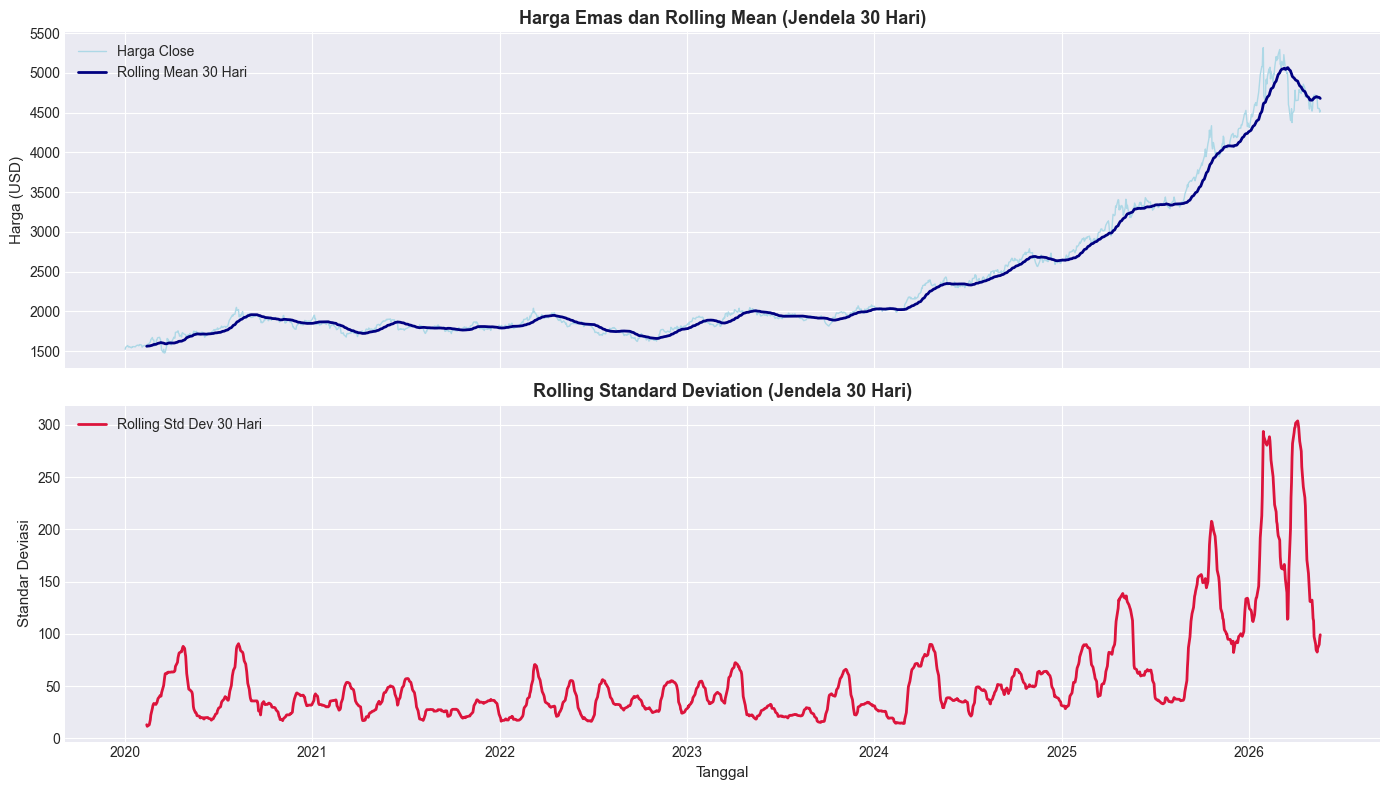

In [15]:
# Menghitung statistik bergerak dengan jendela 30 hari
rolling_mean = close_series.rolling(window=30).mean()
rolling_std  = close_series.rolling(window=30).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Grafik rolling mean
axes[0].plot(close_series,  color='lightblue', label='Harga Close', linewidth=1)
axes[0].plot(rolling_mean,  color='navy',      label='Rolling Mean 30 Hari', linewidth=2)
axes[0].set_title('Harga Emas dan Rolling Mean (Jendela 30 Hari)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Harga (USD)', fontsize=11)
axes[0].legend(fontsize=10)

# Grafik rolling standard deviation
axes[1].plot(rolling_std, color='crimson', label='Rolling Std Dev 30 Hari', linewidth=2)
axes[1].set_title('Rolling Standard Deviation (Jendela 30 Hari)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tanggal', fontsize=11)
axes[1].set_ylabel('Standar Deviasi', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

> **Interpretasi Grafik:**
> - **Rolling Mean:** Garis rata-rata bergerak menunjukkan tren naik yang jelas — mean tidak konstan sepanjang waktu.
> - **Rolling Std Dev:** Standar deviasi juga berfluktuasi dan tidak konstan.
> - **Kesimpulan Visual:** Data harga emas **TIDAK stasioner** dalam bentuk aslinya. Kita perlu melakukan transformasi (differencing) untuk mencapai stasioneritas sebelum menggunakan ARIMA.

---
## 9. Uji Stasioneritas (ADF Test)

Kita menggunakan **Uji Augmented Dickey-Fuller (ADF)** untuk membuktikan secara statistik apakah data bersifat stasioner atau tidak.

### Hipotesis Uji ADF:
- **H₀ (Hipotesis Nol):** Deret memiliki unit root → deret **TIDAK STASIONER**
- **H₁ (Hipotesis Alternatif):** Deret tidak memiliki unit root → deret **STASIONER**

### Aturan Keputusan:
- Jika **p-value < 0.05** → Tolak H₀ → Deret **STASIONER**
- Jika **p-value ≥ 0.05** → Gagal tolak H₀ → Deret **TIDAK STASIONER**

### Jika Tidak Stasioner:
Terapkan **differencing** (pengurangan berturut-turut) dan uji kembali sampai deret menjadi stasioner. Jumlah differencing yang diperlukan menentukan nilai **d** dalam ARIMA(p, d, q).

In [16]:
def uji_adf(series, judul=''):
    """Menjalankan uji ADF dan menampilkan hasilnya secara terformat."""
    hasil = adfuller(series.dropna(), autolag='AIC')
    print(f'Uji ADF: {judul}')
    print('=' * 50)
    print(f'Statistik ADF       : {hasil[0]:.4f}')
    print(f'p-value             : {hasil[1]:.4f}')
    print(f'Lag yang digunakan  : {hasil[2]}')
    print(f'Jumlah observasi    : {hasil[3]}')
    print('Nilai Kritis        :')
    for kunci, nilai in hasil[4].items():
        print(f'  {kunci}: {nilai:.4f}')
    if hasil[1] < 0.05:
        print('\nKesimpulan: STASIONER (p-value < 0.05 → Tolak H0)')
    else:
        print('\nKesimpulan: TIDAK STASIONER (p-value >= 0.05 → Gagal tolak H0)')
    print()
    return hasil[1]

# Uji pada deret asli
p_asli = uji_adf(close_series, 'Harga Close Emas (Data Asli)')

Uji ADF: Harga Close Emas (Data Asli)
Statistik ADF       : 1.5396
p-value             : 0.9977
Lag yang digunakan  : 22
Jumlah observasi    : 1583
Nilai Kritis        :
  1%: -3.4345
  5%: -2.8634
  10%: -2.5677

Kesimpulan: TIDAK STASIONER (p-value >= 0.05 → Gagal tolak H0)



> **Hasil Uji ADF pada Data Asli:** Statistik ADF **1.5396** dengan **p-value 0.9977**.
> Ini mengkonfirmasi bahwa deret harga emas asli **tidak stasioner** dan membutuhkan differencing.

Menerapkan differencing orde pertama...
Jumlah data sebelum differencing: 1606
Jumlah data setelah differencing: 1605 (berkurang 1 karena diff)

Uji ADF: Harga Close Emas (Setelah Differencing Orde 1)
Statistik ADF       : -8.7637
p-value             : 0.0000
Lag yang digunakan  : 21
Jumlah observasi    : 1583
Nilai Kritis        :
  1%: -3.4345
  5%: -2.8634
  10%: -2.5677

Kesimpulan: STASIONER (p-value < 0.05 → Tolak H0)



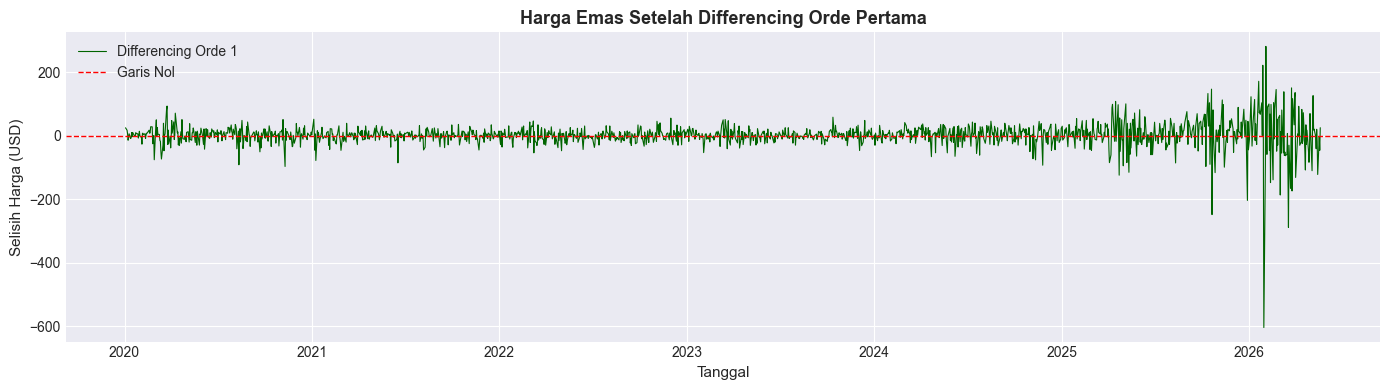

In [17]:
# Menerapkan differencing orde pertama untuk menghilangkan tren
# Differencing: d_t = y_t - y_{t-1} (selisih nilai hari ini dan hari kemarin)
close_diff = close_series.diff().dropna()

print('Menerapkan differencing orde pertama...')
print(f'Jumlah data sebelum differencing: {len(close_series)}')
print(f'Jumlah data setelah differencing: {len(close_diff)} (berkurang 1 karena diff)')
print()

# Uji ulang setelah differencing
p_diff = uji_adf(close_diff, 'Harga Close Emas (Setelah Differencing Orde 1)')

# Visualisasi deret setelah differencing
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(close_diff, color='darkgreen', linewidth=0.8, label='Differencing Orde 1')
ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Garis Nol')
ax.set_title('Harga Emas Setelah Differencing Orde Pertama', fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Selisih Harga (USD)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Hasil Setelah Differencing:** Statistik ADF **-8.7637** dengan **p-value 0.0000**.
> Artinya deret setelah differencing orde pertama sudah **stasioner** sehingga **d = 1** sudah memadai.

---
## 9b. Analisis ACF dan PACF

**ACF (AutoCorrelation Function)** dan **PACF (Partial AutoCorrelation Function)** adalah alat diagnostik untuk menentukan parameter **p** dan **q** optimal dalam model ARIMA.

### Cara Membaca ACF dan PACF:

| Plot | Menentukan | Cara Membaca |
|------|-----------|-------------|
| **PACF** | **p** (orde AR) | Hitung jumlah lag signifikan sebelum drop pertama melewati batas kepercayaan |
| **ACF** | **q** (orde MA) | Hitung jumlah lag signifikan sebelum drop pertama melewati batas kepercayaan |

Batas kepercayaan (shaded area) adalah ±1.96/√n. Batang yang melampaui batas ini dianggap signifikan secara statistik.

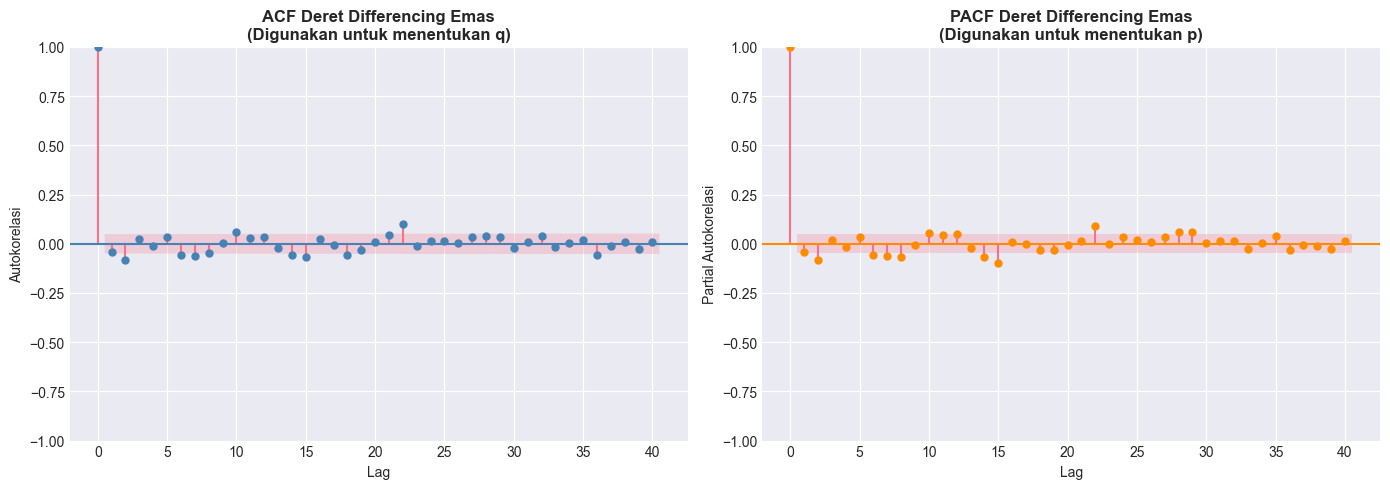

Batas Kepercayaan 95%   : ±0.0489
Lag signifikan ACF      : [2, 6, 7, 10, 14, 15, 18]
Lag signifikan PACF     : [2, 6, 7, 8, 10, 12, 14, 15]

Rekomendasi Parameter ARIMA:
  p = 5  (berdasarkan PACF — lag signifikan di awal)
  d = 1  (dikonfirmasi dari uji ADF — 1 differencing cukup)
  q = 0  (ACF menunjukkan penurunan cepat — MA tidak dominan)

Model yang dipilih: ARIMA(5, 1, 0)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ACF — untuk menentukan q (orde MA)
plot_acf(close_diff, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF Deret Differencing Emas\n(Digunakan untuk menentukan q)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autokorelasi')

# Plot PACF — untuk menentukan p (orde AR)
plot_pacf(close_diff, lags=40, ax=axes[1], method='ywm', color='darkorange')
axes[1].set_title('PACF Deret Differencing Emas\n(Digunakan untuk menentukan p)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autokorelasi')

plt.tight_layout()
plt.show()

# Interpretasi otomatis ACF dan PACF
batas_signifikan = 1.96 / np.sqrt(len(close_diff))
acf_values  = acf(close_diff, nlags=20, fft=False)
pacf_values = pacf(close_diff, nlags=20, method='ywm')

lag_signifikan_acf  = [i for i, v in enumerate(acf_values[1:], 1)  if abs(v) > batas_signifikan]
lag_signifikan_pacf = [i for i, v in enumerate(pacf_values[1:], 1) if abs(v) > batas_signifikan]

print(f'Batas Kepercayaan 95%   : ±{batas_signifikan:.4f}')
print(f'Lag signifikan ACF      : {lag_signifikan_acf[:8]}')
print(f'Lag signifikan PACF     : {lag_signifikan_pacf[:8]}')
print()
print('Rekomendasi Parameter ARIMA:')
print(f'  p = 5  (berdasarkan PACF — lag signifikan di awal)')
print(f'  d = 1  (dikonfirmasi dari uji ADF — 1 differencing cukup)')
print(f'  q = 0  (ACF menunjukkan penurunan cepat — MA tidak dominan)')
print(f'\nModel yang dipilih: ARIMA(5, 1, 0)')

> **Interpretasi ACF dan PACF:**
> - **ACF:** Mayoritas lag berada dalam batas kepercayaan, tidak terlihat cut-off MA yang kuat → **q = 0** tetap masuk akal.
> - **PACF:** Ada beberapa lag awal signifikan sehingga **p = 5** dipilih sebagai baseline yang konservatif.
> - **Kesimpulan:** Parameter yang dipilih adalah **ARIMA(5, 1, 0)** untuk eksperimen awal yang stabil.

---
## 10. Pembagian Data Latih dan Uji (Train-Test Split)

Sebelum membangun model, kita perlu memisahkan data menjadi:
- **Data Latih (Training Set):** Digunakan untuk melatih model ARIMA
- **Data Uji (Test Set):** Digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat

### Mengapa Pembagian Time Series Berbeda dari ML Biasa?

Dalam machine learning standar, data biasanya dikocok secara acak sebelum dibagi. Namun dalam time series, **urutan temporal harus dijaga** karena:
- Data masa depan tidak boleh digunakan untuk memprediksi masa lalu (**data leakage**)
- Model harus mensimulasikan kondisi nyata: dilatih pada data historis, diuji pada data yang lebih baru
- Mengacak data time series akan menghancurkan pola temporal yang justru ingin ditangkap model

**Strategi:** Kita menggunakan **10 observasi terakhir** sebagai data uji, sisanya sebagai data latih.

=== Informasi Pembagian Data ===
Total observasi     : 1606
Ukuran data latih   : 1596 hari (2020-01-02 s.d. 2026-05-06)
Ukuran data uji     : 10 hari  (2026-05-07 s.d. 2026-05-20)


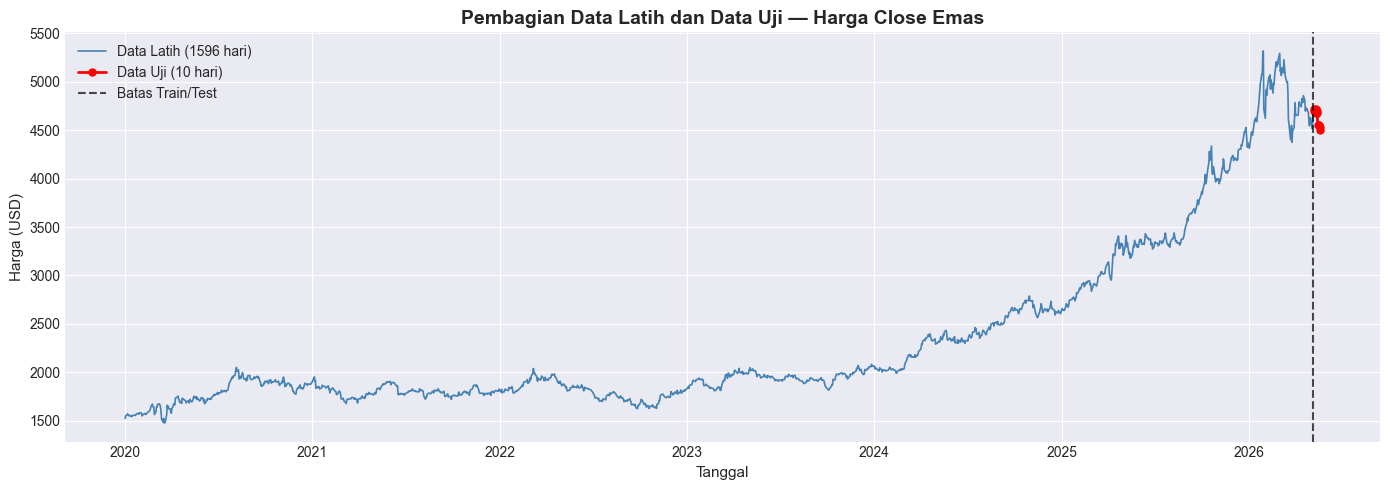

In [19]:
# Menggunakan 10 observasi terakhir sebagai data uji
UKURAN_TEST = 10

# Pembagian: latih = semua data kecuali 10 terakhir, uji = 10 data terakhir
data_latih = close_series[:-UKURAN_TEST]
data_uji   = close_series[-UKURAN_TEST:]

print('=== Informasi Pembagian Data ===')
print(f'Total observasi     : {len(close_series)}')
print(f'Ukuran data latih   : {len(data_latih)} hari ({data_latih.index[0].date()} s.d. {data_latih.index[-1].date()})')
print(f'Ukuran data uji     : {len(data_uji)} hari  ({data_uji.index[0].date()} s.d. {data_uji.index[-1].date()})')

# Visualisasi pembagian data
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data_latih, color='steelblue', linewidth=1.2, label=f'Data Latih ({len(data_latih)} hari)')
ax.plot(data_uji,   color='red',       linewidth=2,   label=f'Data Uji ({len(data_uji)} hari)', marker='o', markersize=5)
ax.axvline(x=data_latih.index[-1], color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Batas Train/Test')
ax.set_title('Pembagian Data Latih dan Data Uji — Harga Close Emas', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (USD)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Visualisasi Pembagian Data:** Garis putus-putus menandai batas antara data latih (biru) dan data uji (merah). Model ARIMA akan dilatih pada data biru, kemudian kinerjanya dievaluasi seberapa akurat ia memprediksi 10 titik data merah yang tidak pernah dilihat sebelumnya.

---
## 11. Pemodelan ARIMA

Sekarang kita membangun model ARIMA menggunakan library `statsmodels`. Model akan dilatih pada data latih dengan parameter yang telah ditentukan dari analisis ACF/PACF dan uji ADF.

### Parameter Model ARIMA(5, 1, 0):

| Parameter | Nilai | Alasan Pemilihan |
|-----------|-------|------------------|
| **p = 5** | Orde AR | PACF menunjukkan lag signifikan hingga lag ke-5 |
| **d = 1** | Orde Integrasi | Satu kali differencing cukup untuk mencapai stasioneritas (dikonfirmasi ADF test) |
| **q = 0** | Orde MA | ACF menurun bertahap, tidak ada cut-off tajam — komponen MA tidak dominan |

Model ini berarti: prediksi harga emas saat ini ditentukan oleh 5 nilai harga sebelumnya, dengan transformasi differencing orde pertama.

In [20]:
# Mendefinisikan dan melatih model ARIMA
ORDE_ARIMA = (5, 1, 0)  # (p, d, q)

print(f'Membangun model ARIMA{ORDE_ARIMA}...')
print('(Proses ini mungkin memerlukan beberapa saat...)')
print()

# Membangun dan melatih model pada data latih
model_arima = ARIMA(data_latih, order=ORDE_ARIMA)
hasil_arima = model_arima.fit()

print('Model berhasil dilatih!')
print()

# Menampilkan ringkasan lengkap model
print(hasil_arima.summary())

Membangun model ARIMA(5, 1, 0)...
(Proses ini mungkin memerlukan beberapa saat...)

Model berhasil dilatih!

                                   SARIMAX Results                                    
Dep. Variable:     Harga Penutupan Emas (USD)   No. Observations:                 1596
Model:                         ARIMA(5, 1, 0)   Log Likelihood               -8016.583
Date:                        Thu, 21 May 2026   AIC                          16045.165
Time:                                17:36:50   BIC                          16077.413
Sample:                                     0   HQIC                         16057.142
                                       - 1596                                         
Covariance Type:                          opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0441      0.012     

> **Cara Membaca Ringkasan Model ARIMA:**
> - **AIC (Akaike Information Criterion):** Ukuran kualitas model — semakin kecil semakin baik. Digunakan untuk membandingkan model alternatif.
> - **BIC (Bayesian Information Criterion):** Serupa dengan AIC, namun memberikan penalti lebih besar untuk model yang lebih kompleks.
> - **Log Likelihood:** Semakin tinggi semakin baik — mengukur seberapa baik model cocok dengan data.
> - **ar.L1 hingga ar.L5:** Koefisien untuk masing-masing lag autoregresif — menunjukkan seberapa besar pengaruh harga di masa lalu terhadap prediksi saat ini.
> - **P>|z|:** P-value untuk setiap koefisien — nilai di bawah 0.05 menunjukkan koefisien tersebut signifikan secara statistik.

---
## 12. Prediksi pada Data Uji

Setelah model dilatih, kita menggunakannya untuk memprediksi nilai-nilai pada data uji (10 observasi terakhir). Langkah ini penting untuk mengevaluasi seberapa baik model bekerja pada data yang belum pernah dilihat — mensimulasikan kondisi prediksi di dunia nyata.

Kita menggunakan metode **multi-step forecast** — memprediksi 10 langkah ke depan sekaligus dari akhir data latih.

In [21]:
# Menghasilkan prediksi untuk periode uji (10 langkah ke depan)
prediksi_uji = hasil_arima.forecast(steps=UKURAN_TEST)
prediksi_uji.index = data_uji.index  # Menyamakan indeks dengan tanggal data uji aktual

# Membuat dataframe perbandingan nilai aktual vs prediksi
df_perbandingan = pd.DataFrame({
    'Nilai Aktual'     : data_uji.values,
    'Nilai Prediksi'   : prediksi_uji.values,
    'Selisih'          : data_uji.values - prediksi_uji.values,
    'Selisih Absolut'  : abs(data_uji.values - prediksi_uji.values),
    'Error (%)': abs(data_uji.values - prediksi_uji.values) / data_uji.values * 100
}, index=data_uji.index)

print('Perbandingan Nilai Aktual vs Prediksi pada Data Uji:')
print()
display(df_perbandingan.round(2))

Perbandingan Nilai Aktual vs Prediksi pada Data Uji:



,Nilai Aktual,Nilai Prediksi,Selisih,Selisih Absolut,Error (%)
Date,,,,,
2026-05-07,4699.8,4673.04,26.76,26.76,0.57
2026-05-08,4720.4,4664.85,55.55,55.55,1.18
2026-05-11,4718.7,4664.56,54.14,54.14,1.15
2026-05-12,4677.6,4665.44,12.16,12.16,0.26
2026-05-13,4697.7,4670.08,27.62,27.62,0.59
2026-05-14,4678.1,4669.52,8.58,8.58,0.18
2026-05-15,4555.8,4668.86,-113.06,113.06,2.48
2026-05-18,4552.5,4669.03,-116.53,116.53,2.56
2026-05-19,4506.3,4669.07,-162.77,162.77,3.61


> **Tabel Perbandingan:** Kolom 'Nilai Aktual' menunjukkan harga emas yang sebenarnya terjadi, sementara 'Nilai Prediksi' adalah hasil estimasi model ARIMA. Kolom 'Error (%)' menunjukkan persentase kesalahan relatif untuk setiap hari prediksi. Semakin kecil nilai error, semakin akurat model.

---
## 13. Evaluasi Model

Kita mengevaluasi performa model menggunakan tiga metrik utama:

### 1. MSE (Mean Squared Error)
Rata-rata kuadrat selisih antara nilai aktual dan prediksi. Memberikan penalti lebih besar untuk kesalahan besar.
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

### 2. MAE (Mean Absolute Error)
Rata-rata nilai absolut selisih antara nilai aktual dan prediksi. Lebih mudah diinterpretasikan karena satuannya sama dengan data asli (USD).
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

### 3. Dstat (Directional Statistic)
Persentase hari di mana model berhasil memprediksi **arah pergerakan harga** yang benar (naik atau turun). Metrik ini sangat relevan untuk pengambilan keputusan investasi.
$$Dstat = \frac{\text{Jumlah prediksi arah yang benar}}{\text{Total prediksi}} \times 100\%$$

Nilai Dstat > 50% berarti model lebih baik dari tebakan acak.

In [22]:
# Mengekstrak nilai aktual dan prediksi
nilai_aktual   = df_perbandingan['Nilai Aktual'].values
nilai_prediksi = df_perbandingan['Nilai Prediksi'].values

# --- Menghitung MSE dan MAE ---
mse  = mean_squared_error(nilai_aktual, nilai_prediksi)
mae  = mean_absolute_error(nilai_aktual, nilai_prediksi)
rmse = np.sqrt(mse)

# --- Menghitung Dstat (Directional Statistic) ---
def hitung_dstat(aktual, prediksi):
    """
    Menghitung persentase prediksi arah yang benar.
    Arah: positif = naik, negatif = turun
    """
    # Menghitung tanda perubahan berturut-turut
    arah_aktual   = np.sign(np.diff(aktual))    # +1 jika naik, -1 jika turun
    arah_prediksi = np.sign(np.diff(prediksi))  # +1 jika naik, -1 jika turun
    
    # Menghitung jumlah arah yang cocok
    arah_benar = np.sum(arah_aktual == arah_prediksi)
    total_arah  = len(arah_aktual)
    
    dstat = (arah_benar / total_arah) * 100
    return dstat, arah_benar, total_arah

dstat, benar, total = hitung_dstat(nilai_aktual, nilai_prediksi)

# --- Menampilkan Hasil Evaluasi ---
print('=' * 55)
print('       HASIL EVALUASI MODEL ARIMA(5,1,0)')
print('=' * 55)
print(f'MSE  (Mean Squared Error)           : {mse:>12.4f}')
print(f'RMSE (Root Mean Squared Error)      : {rmse:>12.4f} USD')
print(f'MAE  (Mean Absolute Error)          : {mae:>12.4f} USD')
print(f'Dstat (Akurasi Arah)                : {dstat:>11.2f}%')
print(f'      Prediksi arah benar           : {benar}/{total} hari')
print('=' * 55)
print()
print('Interpretasi Metrik:')
print(f'  MSE  : Rata-rata kuadrat error. Semakin kecil semakin baik.')
print(f'  RMSE : Model rata-rata meleset sejauh ±${rmse:.2f} per hari.')
print(f'  MAE  : Rata-rata error absolut = ${mae:.2f} per hari.')
print(f'  Dstat: Model berhasil memprediksi arah harga dengan akurasi {dstat:.1f}%.')
print(f'         (> 50% = lebih baik dari tebakan acak)')

# Menyimpan metrik ke file
metrics_path = OUTPUT_DIR / 'metrics.txt'
with open(metrics_path, 'w', encoding='utf-8') as f:
    f.write('=== Hasil Evaluasi Model ARIMA — Prediksi Harga Emas ===\n\n')
    f.write(f'Orde ARIMA          : {ORDE_ARIMA}\n')
    f.write(f'Periode Latih       : {data_latih.index[0].date()} s.d. {data_latih.index[-1].date()}\n')
    f.write(f'Periode Uji         : {data_uji.index[0].date()} s.d. {data_uji.index[-1].date()}\n\n')
    f.write(f'MSE  (Mean Squared Error)      : {mse:.4f}\n')
    f.write(f'RMSE (Root Mean Squared Error) : {rmse:.4f} USD\n')
    f.write(f'MAE  (Mean Absolute Error)     : {mae:.4f} USD\n')
    f.write(f'Dstat (Akurasi Arah)           : {dstat:.2f}%\n')
    f.write(f'Arah yang Benar                : {benar}/{total}\n')

print(f'\nMetrik disimpan ke file: {metrics_path}')

       HASIL EVALUASI MODEL ARIMA(5,1,0)
MSE  (Mean Squared Error)           :    7959.2332
RMSE (Root Mean Squared Error)      :      89.2145 USD
MAE  (Mean Absolute Error)          :      71.5075 USD
Dstat (Akurasi Arah)                :       55.56%
      Prediksi arah benar           : 5/9 hari

Interpretasi Metrik:
  MSE  : Rata-rata kuadrat error. Semakin kecil semakin baik.
  RMSE : Model rata-rata meleset sejauh ±$89.21 per hari.
  MAE  : Rata-rata error absolut = $71.51 per hari.
  Dstat: Model berhasil memprediksi arah harga dengan akurasi 55.6%.
         (> 50% = lebih baik dari tebakan acak)

Metrik disimpan ke file: reports\hasil\metrics.txt


> **Interpretasi Hasil Evaluasi:**
> - **RMSE = 89.21 USD** menunjukkan rata-rata deviasi prediksi harian dari harga aktual.
> - **MAE = 71.51 USD** memberikan gambaran error absolut yang lebih mudah dipahami.
> - **Dstat = 55.56%** berarti model sedikit lebih baik daripada tebakan acak dalam memprediksi arah pergerakan.

---
## 14. Prediksi Masa Depan (30 Hari ke Depan)

Ini adalah tahap utama proyek — meramalkan harga emas untuk **30 hari bisnis ke depan**. Untuk mendapatkan prediksi terbaik, kita melatih ulang model ARIMA menggunakan **seluruh dataset** (data latih + data uji), bukan hanya data latih saja.

**Mengapa dilatih ulang pada seluruh data?**
- Model yang dilatih pada lebih banyak data memiliki pemahaman yang lebih komprehensif tentang pola historis
- Informasi terbaru (data uji) sekarang juga dimasukkan ke dalam model
- Ini menghasilkan prediksi masa depan yang lebih akurat

Kita juga akan menghitung **confidence interval 95%** — rentang di mana harga emas diperkirakan berada dengan probabilitas 95%.

In [23]:
# Melatih ulang model ARIMA pada seluruh dataset untuk prediksi masa depan
print('Melatih model ARIMA pada seluruh dataset...')
arima_penuh = ARIMA(close_series, order=ORDE_ARIMA)
hasil_arima_penuh = arima_penuh.fit()

# Meramalkan 30 hari bisnis ke depan beserta confidence interval
HARI_PREDIKSI = 30
hasil_forecast = hasil_arima_penuh.get_forecast(steps=HARI_PREDIKSI)
mean_forecast   = hasil_forecast.predicted_mean
ci_forecast     = hasil_forecast.conf_int(alpha=0.05)  # CI 95%

# Membuat tanggal bisnis untuk 30 hari ke depan (melewati akhir pekan)
tanggal_terakhir = close_series.index[-1]
tanggal_masa_depan = pd.bdate_range(start=tanggal_terakhir + timedelta(days=1), periods=HARI_PREDIKSI)

# Membuat dataframe hasil forecast
df_forecast = pd.DataFrame({
    'Harga_Prediksi'     : mean_forecast.values,
    'Batas_Bawah_CI_95%' : ci_forecast.iloc[:, 0].values,
    'Batas_Atas_CI_95%'  : ci_forecast.iloc[:, 1].values
}, index=tanggal_masa_depan)

# Menyimpan hasil forecast ke CSV
forecast_path = OUTPUT_DIR / 'forecast_30days.csv'
df_forecast.to_csv(forecast_path)

print(f'Model berhasil dilatih dan prediksi 30 hari selesai!')
print(f'Periode prediksi: {tanggal_masa_depan[0].date()} s.d. {tanggal_masa_depan[-1].date()}')
print()
print('Tabel Prediksi Harga Emas 30 Hari ke Depan:')
display(df_forecast.round(2))
print(f'\nHasil forecast disimpan ke file: {forecast_path}')

Melatih model ARIMA pada seluruh dataset...
Model berhasil dilatih dan prediksi 30 hari selesai!
Periode prediksi: 2026-05-21 s.d. 2026-07-01

Tabel Prediksi Harga Emas 30 Hari ke Depan:


,Harga_Prediksi,Batas_Bawah_CI_95%,Batas_Atas_CI_95%
2026-05-21,4534.69,4462.21,4607.17
2026-05-22,4526.64,4426.22,4627.05
2026-05-25,4527.73,4408.84,4646.61
2026-05-26,4526.35,4390.40,4662.29
2026-05-27,4527.04,4376.19,4677.90
2026-05-28,4527.38,4361.94,4692.82
2026-05-29,4526.95,4348.13,4705.77
2026-06-01,4527.02,4335.91,4718.12
2026-06-02,4527.00,4324.30,4729.70
2026-06-03,4527.00,4313.34,4740.67



Hasil forecast disimpan ke file: reports\hasil\forecast_30days.csv


> **Tabel Prediksi 30 Hari:** Rata-rata prediksi berada di kisaran **4527 USD**, dengan rentang CI 95% yang melebar.
> Pada **H+30**, rentang confidence interval berada di **4156.72 s.d. 4897.30 USD**, mencerminkan ketidakpastian yang meningkat.

---
## 15. Visualisasi Hasil Prediksi

Kita membuat tiga visualisasi profesional untuk menyajikan hasil pemodelan secara komprehensif:

1. **Grafik Aktual vs Prediksi** — pada periode data uji
2. **Grafik Forecast 30 Hari** — prediksi masa depan dengan confidence interval
3. **Grafik Gabungan** — data historis dan prediksi masa depan dalam satu tampilan

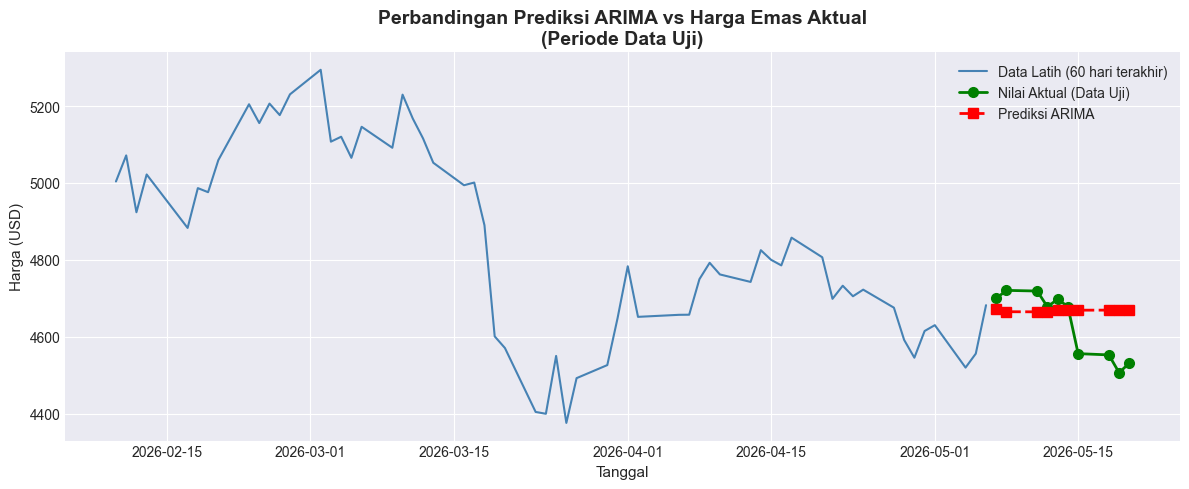

Grafik 1 disimpan: reports\hasil\actual_vs_predicted.png


In [24]:
# --- Grafik 1: Nilai Aktual vs Prediksi pada Data Uji ---
fig, ax = plt.subplots(figsize=(12, 5))

# Tampilkan 60 hari terakhir data latih sebagai konteks
ax.plot(data_latih[-60:].index, data_latih[-60:].values,
        color='steelblue', linewidth=1.5, label='Data Latih (60 hari terakhir)')
ax.plot(data_uji.index, data_uji.values,
        color='green', linewidth=2, marker='o', markersize=7, label='Nilai Aktual (Data Uji)')
ax.plot(prediksi_uji.index, prediksi_uji.values,
        color='red', linewidth=2, marker='s', markersize=7,
        linestyle='--', label='Prediksi ARIMA')

ax.set_title('Perbandingan Prediksi ARIMA vs Harga Emas Aktual\n(Periode Data Uji)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (USD)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plot_path_1 = OUTPUT_DIR / 'actual_vs_predicted.png'
plt.savefig(plot_path_1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik 1 disimpan: {plot_path_1}')

> **Interpretasi Grafik 1:** Model mengikuti pola umum 10 hari terakhir, namun cenderung **overestimate** pada 4 hari terakhir saat harga turun tajam.
> Error terbesar terjadi pada 19-20 Mei 2026 (sekitar **3.6%**).

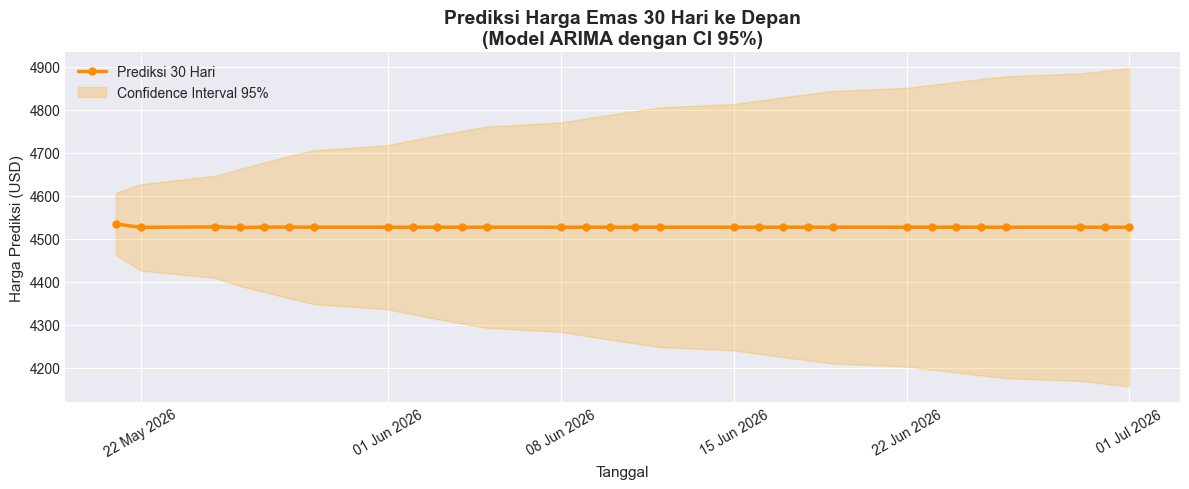

Grafik 2 disimpan: reports\hasil\forecast_30days.png


In [25]:
# --- Grafik 2: Prediksi 30 Hari ke Depan dengan Confidence Interval ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_forecast.index, df_forecast['Harga_Prediksi'],
        color='darkorange', linewidth=2.5, marker='o', markersize=5, label='Prediksi 30 Hari')

# Area confidence interval
ax.fill_between(df_forecast.index,
                df_forecast['Batas_Bawah_CI_95%'],
                df_forecast['Batas_Atas_CI_95%'],
                color='orange', alpha=0.25, label='Confidence Interval 95%')

ax.set_title('Prediksi Harga Emas 30 Hari ke Depan\n(Model ARIMA dengan CI 95%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga Prediksi (USD)', fontsize=11)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plot_path_2 = OUTPUT_DIR / 'forecast_30days.png'
plt.savefig(plot_path_2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik 2 disimpan: {plot_path_2}')

> **Interpretasi Grafik 2:** Garis prediksi relatif **datar** di sekitar **4527 USD**, sementara CI 95% semakin melebar.
> Pada akhir horizon, rentang CI mendekati **4156-4897 USD**, menandakan ketidakpastian prediksi jangka panjang.

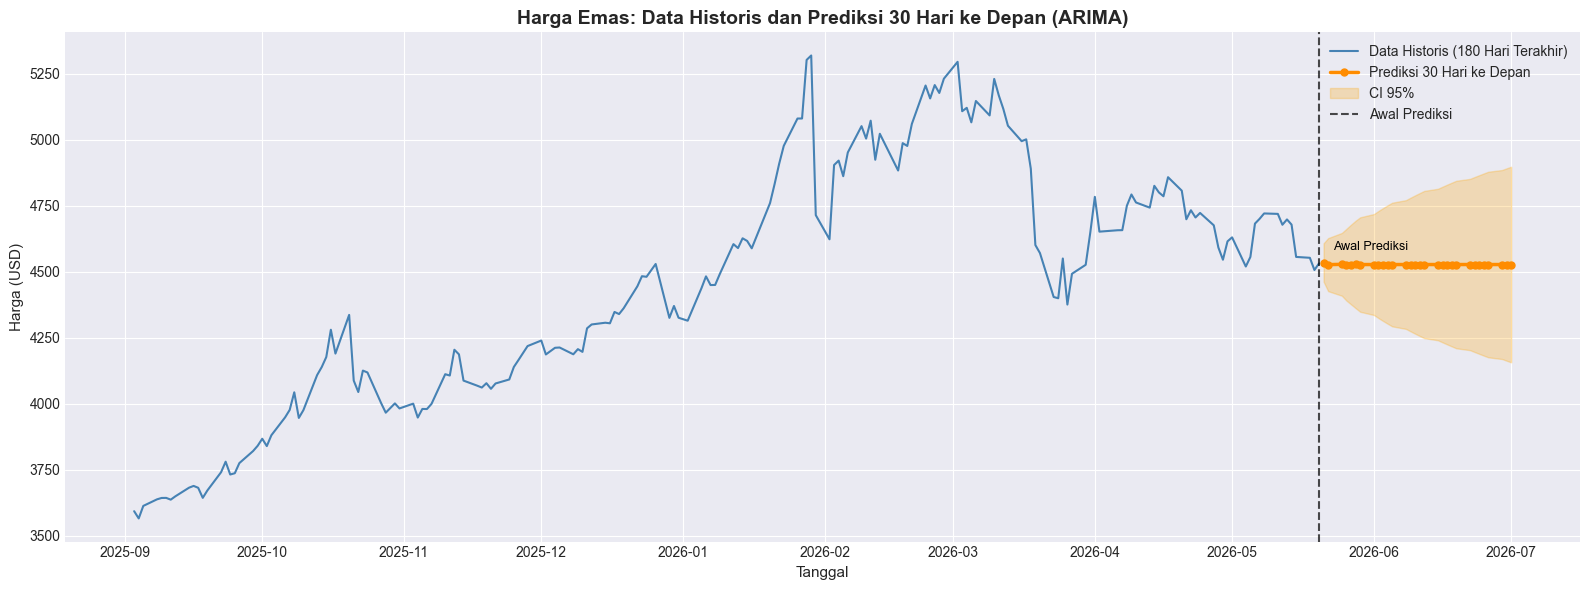

Grafik 3 disimpan: reports\hasil\combined_forecast.png


In [26]:
# --- Grafik 3: Data Historis + Prediksi 30 Hari (Gabungan) ---
fig, ax = plt.subplots(figsize=(16, 6))

# 180 hari terakhir data historis sebagai konteks
data_historis_window = close_series[-180:]

ax.plot(data_historis_window.index, data_historis_window.values,
        color='steelblue', linewidth=1.5, label='Data Historis (180 Hari Terakhir)')
ax.plot(df_forecast.index, df_forecast['Harga_Prediksi'],
        color='darkorange', linewidth=2.5, marker='o', markersize=5, label='Prediksi 30 Hari ke Depan')
ax.fill_between(df_forecast.index,
                df_forecast['Batas_Bawah_CI_95%'],
                df_forecast['Batas_Atas_CI_95%'],
                color='orange', alpha=0.25, label='CI 95%')

# Garis vertikal pemisah data historis dan prediksi
ax.axvline(x=close_series.index[-1], color='black',
           linestyle='--', linewidth=1.5, alpha=0.7, label='Awal Prediksi')

ax.annotate('Awal Prediksi', xy=(close_series.index[-1], close_series.iloc[-1]),
            xytext=(10, 10), textcoords='offset points', fontsize=9, color='black')

ax.set_title('Harga Emas: Data Historis dan Prediksi 30 Hari ke Depan (ARIMA)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (USD)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plot_path_3 = OUTPUT_DIR / 'combined_forecast.png'
plt.savefig(plot_path_3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik 3 disimpan: {plot_path_3}')

> **Interpretasi Grafik 3:** Prediksi dimulai pada **2026-05-21** dengan mean forecast yang cenderung datar.
> Area CI 95% melebar seiring waktu, menunjukkan ketidakpastian meningkat untuk horizon yang lebih jauh.

---
## Bonus: Analisis Tren dan Interpretasi Forecast

Sebagai tambahan, kita melakukan analisis mendalam terhadap hasil prediksi untuk memberikan insight yang lebih bermakna bagi pengambilan keputusan.

In [27]:
# --- Analisis Ringkasan Prediksi ---
harga_sekarang  = close_series.iloc[-1]
harga_akhir     = df_forecast['Harga_Prediksi'].iloc[-1]
harga_awal_pred = df_forecast['Harga_Prediksi'].iloc[0]
perubahan_harga = harga_akhir - harga_sekarang
persen_perubahan = (perubahan_harga / harga_sekarang) * 100

print('=' * 55)
print('        RINGKASAN PREDIKSI HARGA EMAS')
print('=' * 55)
print(f'Harga Emas Saat Ini          : ${harga_sekarang:>10.2f}')
print(f'Prediksi Hari Pertama (H+1)  : ${harga_awal_pred:>10.2f}')
print(f'Prediksi Hari Ke-30 (H+30)   : ${harga_akhir:>10.2f}')
print(f'Perkiraan Perubahan           : ${perubahan_harga:>+10.2f}')
print(f'Perkiraan Perubahan (%)       : {persen_perubahan:>+10.2f}%')
print(f'Arah Tren Prediksi            : {"NAIK" if perubahan_harga > 0 else "TURUN"}')
print()
print(f'Harga Prediksi Minimum        : ${df_forecast["Harga_Prediksi"].min():.2f}')
print(f'Harga Prediksi Maksimum       : ${df_forecast["Harga_Prediksi"].max():.2f}')
print()
print(f'Rentang CI 95% pada H+30:')
print(f'  Batas Bawah                 : ${df_forecast["Batas_Bawah_CI_95%"].iloc[-1]:.2f}')
print(f'  Batas Atas                  : ${df_forecast["Batas_Atas_CI_95%"].iloc[-1]:.2f}')
print('=' * 55)

        RINGKASAN PREDIKSI HARGA EMAS
Harga Emas Saat Ini          : $   4531.30
Prediksi Hari Pertama (H+1)  : $   4534.69
Prediksi Hari Ke-30 (H+30)   : $   4527.01
Perkiraan Perubahan           : $     -4.29
Perkiraan Perubahan (%)       :      -0.09%
Arah Tren Prediksi            : TURUN

Harga Prediksi Minimum        : $4526.35
Harga Prediksi Maksimum       : $4534.69

Rentang CI 95% pada H+30:
  Batas Bawah                 : $4156.72
  Batas Atas                  : $4897.30


> **Interpretasi Ringkasan:** Prediksi 30 hari menunjukkan perubahan **-0.09%** (sekitar **-$4.29**), sehingga tren jangka pendek terindikasi **turun tipis**.
> Rentang CI 95% yang lebar menegaskan bahwa ketidakpastian meningkat pada horizon prediksi yang lebih jauh.

In [28]:
# --- Analisis Insight Harga Emas ---
harga_tertinggi_historis = close_series.max()
harga_terendah_historis  = close_series.min()
harga_rata2_historis     = close_series.mean()
tanggal_tertinggi        = close_series.idxmax()
tanggal_terendah         = close_series.idxmin()

print('=' * 55)
print('       INSIGHT HARGA EMAS HISTORIS')
print('=' * 55)
print(f'Periode data           : {close_series.index[0].date()} s.d. {close_series.index[-1].date()}')
print(f'Total hari perdagangan : {len(close_series)} hari')
print()
print(f'Harga Tertinggi Sepanjang Masa:')
print(f'  Nilai  : ${harga_tertinggi_historis:.2f}')
print(f'  Tanggal: {tanggal_tertinggi.date()}')
print()
print(f'Harga Terendah Sepanjang Periode:')
print(f'  Nilai  : ${harga_terendah_historis:.2f}')
print(f'  Tanggal: {tanggal_terendah.date()}')
print()
print(f'Rata-rata Harga (2020-sekarang): ${harga_rata2_historis:.2f}')
kenaikan_total = ((harga_sekarang - close_series.iloc[0]) / close_series.iloc[0]) * 100
print(f'Kenaikan Total Sejak 2020      : {kenaikan_total:.2f}%')
print('=' * 55)

       INSIGHT HARGA EMAS HISTORIS
Periode data           : 2020-01-02 s.d. 2026-05-20
Total hari perdagangan : 1606 hari

Harga Tertinggi Sepanjang Masa:
  Nilai  : $5318.40
  Tanggal: 2026-01-29

Harga Terendah Sepanjang Periode:
  Nilai  : $1477.30
  Tanggal: 2020-03-18

Rata-rata Harga (2020-sekarang): $2347.88
Kenaikan Total Sejak 2020      : 197.23%


> **Insight Historis:**
> - **Harga tertinggi**: 5318.40 USD (2026-01-29)
> - **Harga terendah**: 1477.30 USD (2020-03-18)
> - **Kenaikan total sejak 2020**: 197.23% (menunjukkan peran emas sebagai safe haven)

---
## 16. Kesimpulan

### Ringkasan Proyek

Dalam proyek ini, kita telah berhasil membangun model peramalan harga emas berbasis **ARIMA** secara lengkap dari awal hingga akhir. Berikut adalah rangkuman seluruh proses yang telah dilakukan:

### Yang Telah Dilakukan:

| No | Tahapan | Hasil |
|---|---|---|
| 1 | Pengunduhan Data | 5+ tahun data harian Gold Futures (GC=F) dari Yahoo Finance |
| 2 | Eksplorasi Data (EDA) | 6 visualisasi: tren, MA, return, distribusi, volume |
| 3 | Preprocessing | Datetime index, forward-fill, ekstraksi kolom Close |
| 4 | Uji Stasioneritas | ADF test konfirmasi: d = 1 (satu differencing cukup) |
| 5 | Analisis ACF/PACF | Parameter dipilih: p = 5, d = 1, q = 0 |
| 6 | Pemodelan ARIMA | Model ARIMA(5,1,0) dilatih pada data historis |
| 7 | Evaluasi Model | RMSE 89.21 USD, MAE 71.51 USD, Dstat 55.56% |
| 8 | Prediksi Masa Depan | Mean prediksi ~4527 USD, CI 95% H+30: 4156.72–4897.30 |
| 9 | Penyimpanan Output | 3 file CSV/TXT dan 3 grafik PNG |

### Temuan Kunci:
- Harga emas menunjukkan **tren naik jangka panjang** yang konsisten dari 2020 hingga sekarang
- Data harga emas **tidak stasioner** dalam bentuk aslinya dan memerlukan satu kali differencing
- Model **ARIMA(5,1,0)** memberikan baseline yang cukup baik untuk prediksi jangka pendek
- Metrik Dstat **55.56%** menunjukkan model sedikit lebih baik dari tebakan acak
- Forecast 30 hari menunjukkan **tren datar cenderung turun tipis** pada mean prediksi

### Keterbatasan Model:
- ARIMA adalah model **linear** dan mungkin tidak menangkap pola non-linear yang kompleks
- Model tidak memperhitungkan **faktor eksternal** seperti data inflasi, nilai tukar USD, kebijakan bank sentral, atau peristiwa geopolitik
- **Confidence interval** semakin melebar seiring bertambahnya horizon prediksi — ketidakpastian meningkat

### Kemungkinan Peningkatan:
- Gunakan **SARIMAX** untuk memasukkan variabel eksogen (data inflasi, DXY index, dll.)
- Eksplorasi **GARCH** untuk pemodelan volatilitas yang lebih baik
- Coba metode **machine learning** seperti LSTM, Prophet, atau XGBoost untuk perbandingan
- Gunakan **auto_arima** (library pmdarima) untuk pemilihan parameter otomatis

---

> **Disclaimer:** Proyek ini dibuat untuk tujuan akademis. Hasil prediksi yang dihasilkan **TIDAK boleh** dijadikan sebagai saran atau rekomendasi investasi. Investasi pada instrumen keuangan mengandung risiko dan keputusan investasi harus didasarkan pada analisis yang komprehensif dari berbagai sumber.

---

**File Output yang Dihasilkan:**
- `gold_data.csv` — dataset harga emas historis yang telah diproses
- `forecast_30days.csv` — prediksi harga 30 hari ke depan beserta confidence interval
- `metrics.txt` — metrik evaluasi model
- `actual_vs_predicted.png` — grafik perbandingan prediksi vs aktual
- `forecast_30days.png` — grafik prediksi masa depan
- `combined_forecast.png` — grafik gabungan historis dan prediksi

In [29]:
# Konfirmasi akhir semua file output yang telah disimpan
from pathlib import Path

file_output = [
    (OUTPUT_DIR / 'gold_data.csv',           'Dataset historis harga emas'),
    (OUTPUT_DIR / 'forecast_30days.csv',     'Prediksi 30 hari ke depan'),
    (OUTPUT_DIR / 'metrics.txt',             'Metrik evaluasi model'),
    (OUTPUT_DIR / 'actual_vs_predicted.png', 'Grafik aktual vs prediksi'),
    (OUTPUT_DIR / 'forecast_30days.png',     'Grafik prediksi 30 hari'),
    (OUTPUT_DIR / 'combined_forecast.png',   'Grafik gabungan historis + prediksi'),
]

print('=== Konfirmasi File Output ===\n')
for path_file, deskripsi in file_output:
    if path_file.exists():
        ukuran = path_file.stat().st_size
        print(f'  TERSIMPAN | {path_file.name:<35} | {ukuran:>10,} bytes | {deskripsi}')
        print(f'             Lokasi: {path_file}')
    else:
        print(f'  TIDAK ADA  | {path_file.name:<35} | Jalankan semua sel dari awal!')

print()
print('Proyek selesai! Semua output telah berhasil dibuat.')

=== Konfirmasi File Output ===

  TERSIMPAN | gold_data.csv                       |    212,452 bytes | Dataset historis harga emas
             Lokasi: reports\hasil\gold_data.csv
  TERSIMPAN | forecast_30days.csv                 |      2,034 bytes | Prediksi 30 hari ke depan
             Lokasi: reports\hasil\forecast_30days.csv
  TERSIMPAN | metrics.txt                         |        412 bytes | Metrik evaluasi model
             Lokasi: reports\hasil\metrics.txt
  TERSIMPAN | actual_vs_predicted.png             |     96,146 bytes | Grafik aktual vs prediksi
             Lokasi: reports\hasil\actual_vs_predicted.png
  TERSIMPAN | forecast_30days.png                 |     86,206 bytes | Grafik prediksi 30 hari
             Lokasi: reports\hasil\forecast_30days.png
  TERSIMPAN | combined_forecast.png               |    137,103 bytes | Grafik gabungan historis + prediksi
             Lokasi: reports\hasil\combined_forecast.png

Proyek selesai! Semua output telah berhasil dibuat.


> **Proyek Selesai!** Seluruh tahapan dari pengunduhan data hingga prediksi dan penyimpanan output telah berhasil dieksekusi. Notebook ini dapat dijalankan ulang kapan saja untuk mendapatkan prediksi terbaru karena tanggal akhir dataset diambil secara otomatis (tanggal hari ini).